<a href="https://colab.research.google.com/github/malcolmlett/training-instrumentation-toolkit/blob/main/doc/blog-202503/gradient-collapse.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install Training Instrumentation Toolkit
# (locked to specific git revision so this notebook always works)
import os
import sys
if not os.path.isdir('training-instrumentation-toolkit'):
  !git clone https://github.com/malcolmlett/training-instrumentation-toolkit.git
  !cd training-instrumentation-toolkit && git checkout c9fade6
sys.path.append('training-instrumentation-toolkit')

# Imports
import train_instrumentation as tinstr
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.transforms as transforms

Cloning into 'training-instrumentation-toolkit'...
remote: Enumerating objects: 1319, done.
remote: Counting objects: 100% (80/80), done.
remote: Compressing objects: 100% (65/65), done.
remote: Total 1319 (delta 40), reused 32 (delta 15), pack-reused 1239 (from 1)
Receiving objects: 100% (1319/1319), 92.17 MiB | 12.11 MiB/s, done.
Resolving deltas: 100% (789/789), done.
Note: switching to 'c9fade6'.

You are in 'detached HEAD' state. You can look around, make experimental
changes and commit them, and you can discard any commits you make in this
state without impacting any branches by switching back to a branch.

If you want to create a new branch to retain commits you create, you may
do so (now or later) by using -c with the switch command. Example:

  git switch -c <new-branch-name>

Or undo this operation with:

  git switch -

Turn off this advice by setting config variable advice.detachedHead to false

HEAD is now at c9fade6 First time got the maths to work


## Dataset Pipeline


In [2]:
# Load CIFAR-10 dataset
(x_train, _), (x_test, _) = tf.keras.datasets.cifar10.load_data()
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 25s 0us/step


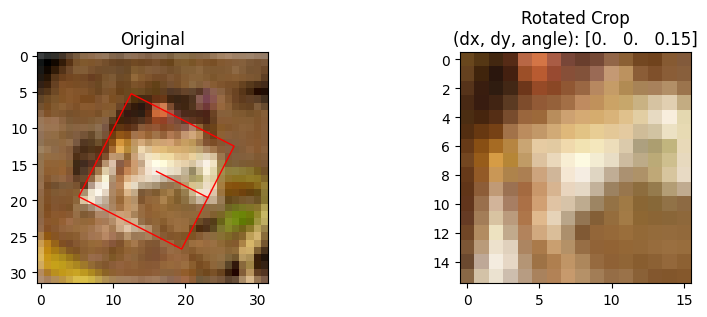

In [3]:
# image manipulation function
def rotated_crop(image, dx, dy, da):
    """
    Takes a 50% crop of the source image after applying a positional and angular
    offset relative to the image's centre.
    For example, (dx,dy,da) = (-0.25,0,0.5) will take a crop centred one quarter
    of the image width to the left from the source image centre and rotated
    45 degrees (50% of 180 in whichever direction the positive direction happens
    to take).
    Args:
      image: source image
      dx: float in range -0.5 .. +0.5 (fraction of width)
      dy: float in range -0.5 .. +0.5 (fraction of height)
      da: float in range -1.0 .. +1.0 (fraction of radians)
    Returns:
      cropped image
    """
    # Image dimensions
    img_height, img_width = image.shape[0], image.shape[1]
    img_centre_x = img_width // 2
    img_centre_y = img_height // 2
    crop_size = img_height // 2  # 50% of original size (16x16 for CIFAR-10)
    crop_centre_x = crop_size // 2
    crop_centre_y = crop_size // 2

    # Step 1: Rotate crop window about its top-left corner
    # - assuming crop-mid is at (x,y)=(8,8)
    # - net result is that the crop-mid will move to crop_mid' = tf.linalg.matvec(R, crop_mid)
    R = tf.stack([
        [tf.cos(da * np.pi), -tf.sin(da * np.pi), 0],
        [tf.sin(da * np.pi), tf.cos(da * np.pi), 0],
        [0.0, 0.0, 1.0]
    ])
    R_neg = tf.stack([
        [tf.cos(-da * np.pi), -tf.sin(-da * np.pi), 0],
        [tf.sin(-da * np.pi), tf.cos(-da * np.pi), 0],
        [0.0, 0.0, 1.0]
    ])

    # Step 2a: Calculate crop-mid after rotation
    crop_mid = [crop_centre_x, crop_centre_y, 1.]
    crop_mid = tf.linalg.matvec(R, crop_mid)

    # Step 2b: Translate rotated location of crop-mid back to it's original position
    Tv = [crop_centre_x - crop_mid[0], crop_centre_y - crop_mid[1], 1.]

    # Step 2c: translate crop-mid to target location on source image
    tx = img_centre_x + dx * img_width - crop_centre_x
    ty = img_centre_y + dy * img_height - crop_centre_y
    Tv = [Tv[0] + tx, Tv[1] + ty, 1.]

    # Step 2d: reverse rotation impact before applying
    # - we'll apply the translation first, so it's ultimate effect is then rotated,
    #   so we counteract that effect by pre-rotating in the opposite direction
    Tv = tf.linalg.matvec(R_neg, Tv)
    T = tf.stack([
        [1.0, 0.0, Tv[0]],
        [0.0, 1.0, Tv[1]],
        [0.0, 0.0, 1.0]
    ])

    # combine transformations: R * T
    # - technically this is applying T first, and then R
    # - has effect of rotating crop window by R, and then translating by R(T)
    h_matrix = tf.linalg.matmul(R, T)

    # Flatten to 8 parameters (last is 1)
    h_matrix = tf.reshape(h_matrix, [-1])[:-1]

    # Apply projective transform
    rotated_crop = tf.raw_ops.ImageProjectiveTransformV3(
        images=tf.expand_dims(image, 0),  # Add batch dimension
        transforms=tf.expand_dims(h_matrix, 0),  # Add batch dimension
        output_shape=[crop_size, crop_size],
        interpolation='BILINEAR',
        fill_value=0.0,
        fill_mode='CONSTANT'
    )[0]  # Remove batch dimension

    return rotated_crop

def draw_crop_template(image, transform):
  dx, dy, da = transform
  centre_x = image.shape[1] * (0.5 + dx)
  centre_y = image.shape[0] * (0.5 + dy)
  width = image.shape[1] // 2
  height = image.shape[0] // 2
  radians = da * np.pi

  # draw a rectangle showing the outline of where the crop was taken from
  ax = plt.gca()
  rect = patches.Rectangle((centre_x - width/2, centre_y - height/2), width, height, linewidth=1, edgecolor='r', facecolor='none')
  t = transforms.Affine2D().rotate_deg_around(centre_x, centre_y, radians * 180 / np.pi)
  rect.set_transform(t + ax.transData)
  ax.add_patch(rect)

  # draw a rotated 0-degrees line to indicate the rotation.
  line_end_x = centre_x + width / 2
  line_end_y = centre_y
  rotated_endpoint = t.transform([(line_end_x, line_end_y)])[0]
  ax.plot([centre_x, rotated_endpoint[0]], [centre_y, rotated_endpoint[1]], color='r', linewidth=1)

def show_data_sample(inputs, output):
  (image, cropped) = inputs
  transform = output
  plt.figure(figsize=(10, 3))

  plt.subplot(1, 2, 1)
  plt.title("Original")
  plt.imshow(image)
  draw_crop_template(image, transform)

  plt.subplot(1, 2, 2)
  plt.title(f"Rotated Crop\n(dx, dy, angle): {transform}")
  plt.imshow(cropped)
  plt.show()

image = x_train[0]
transform = tf.constant(([0.0, 0.0, 0.15]))
cropped = rotated_crop(image, dx=transform[0], dy=transform[1], da=transform[2])
show_data_sample((image, cropped), transform)

Original shape: (32, 32, 32, 3)
Rotated Crop shape: (32, 16, 16, 3)
Transformation shape: (32, 3)


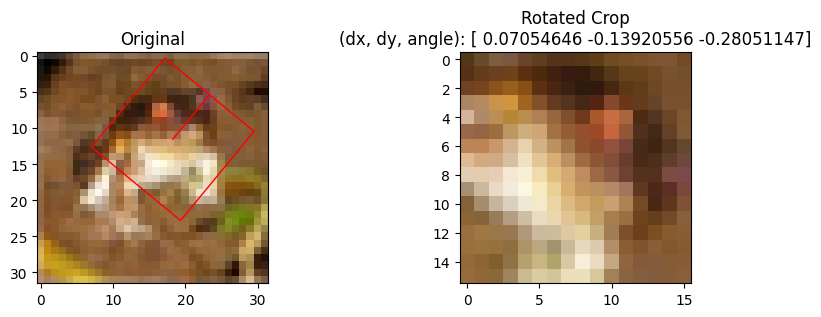

Time for 100 batches: 0.73 seconds
Total batches: 1563


In [4]:
# pre-processing pipeline
def preprocess_image(image):
    # Generate random translation and rotation
    # - dx/dy in range -0.5..+0.5 (fraction of width/height)
    # - da    in range -1.0..+1.0 (radians)
    # - small stddev
    dx = tf.clip_by_value(tf.random.normal([], mean=0, stddev=0.5/4), -0.5, 0.5)
    dy = tf.clip_by_value(tf.random.normal([], mean=0, stddev=0.5/4), -0.5, 0.5)
    da = tf.clip_by_value(tf.random.normal([], mean=0, stddev=1.0/4), -1.0, 1.0)

    # Take rotated crop
    cropped = rotated_crop(image, dx, dy, da)

    # construct as input/output tuples
    transform = tf.stack([dx, dy, da])
    return (image, cropped), transform

def prepared_dataset():
  train_dataset = tf.data.Dataset.from_tensor_slices(x_train)
  train_dataset = train_dataset.map(
      preprocess_image,
      num_parallel_calls=tf.data.AUTOTUNE
  )
  return train_dataset

# Create the dataset pipeline
train_dataset = prepared_dataset().batch(32).prefetch(tf.data.AUTOTUNE)

# Test and visualize
for (original, cropped), transform in train_dataset.take(1):
    print("Original shape:", original.shape)         # [batch, 32, 32, 3]
    print("Rotated Crop shape:", cropped.shape) # [batch, 16, 16, 3]
    print("Transformation shape:", transform.shape)  # [batch, 3]

    show_data_sample((original[0], cropped[0]), transform[0])

# Optional: Time the pipeline
import time
start = time.time()
for _ in train_dataset.take(100):  # Process 100 batches
    pass
print(f"Time for 100 batches: {time.time() - start:.2f} seconds")
print(f"Total batches: {len(train_dataset)}")

## Model

In [30]:
def basic_conv_model():
    original_input = tf.keras.Input(shape=(32, 32, 3), name="original_image")
    crop_input = tf.keras.Input(shape=(16, 16, 3), name="crop")

    # A CNN stack for the 32x32 original image
    x1 = layers.Conv2D(filters=32, kernel_size=3, activation='relu', padding='same', name='x1_conv2d_1')(original_input)
    x1 = layers.MaxPooling2D(pool_size=2, name='x1_pool2d_1')(x1)
    x1 = layers.Conv2D(filters=64, kernel_size=3, activation='relu', padding='same', name='x1_conv2d_2')(x1)
    x1 = layers.MaxPooling2D(pool_size=2, name='x1_pool2d_2')(x1)
    x1 = layers.Flatten(name='x1_flatten')(x1)
    x1 = layers.Dense(128, activation='relu', name='x1_dense_1')(x1)

    # Separate CNN stack for the 16x16 cropped input
    x2 = layers.Conv2D(filters=32, kernel_size=3, activation='relu', padding='same', name='x2_conv2d_1')(crop_input)
    x2 = layers.MaxPooling2D(pool_size=2, name='x2_pool2d_1')(x2)
    x2 = layers.Conv2D(filters=64, kernel_size=3, activation='relu', padding='same', name='x2_conv2d_2')(x2)
    x2 = layers.MaxPooling2D(pool_size=2, name='x2_pool2d_2')(x2)
    x2 = layers.Flatten(name='x2_flatten')(x2)
    x2 = layers.Dense(128, activation='relu', name='x2_dense_1')(x2)

    # Combine feature vectors
    merged = layers.Concatenate(name='head_concat1')([x1, x2])

    # Fully-connected “head” to predict [dx, dy, da]
    # - This final Dense layer has 3 units; a linear activation is typical for regression tasks.
    # - You may experiment with ‘tanh’ if you want explicit output bounding. E.g. for (dx, dy) in [-0.5, 0.5], (da) in [-1.0, 1.0],
    # you could scale appropriately. But linear is often simplest to start with.
    outputs = layers.Dense(3, activation='linear', name='head_dense1')(merged)

    return tf.keras.Model(inputs=[original_input, crop_input], outputs=outputs)

# Uncomment if you just want to see the model summary
#model = basic_conv_model()
#model.compile(
#    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
#    loss='mean_squared_error',
#    metrics=[]
#)
#model.summary()

Model: "functional_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ original_image            │ (None, 32, 32, 3)      │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ crop (InputLayer)         │ (None, 16, 16, 3)      │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ x1_conv2d_1 (Conv2D)      │ (None, 32, 32, 32)     │            896 │ original_image[0][0]   │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ x2_conv2d_1 (Conv2D)      │ (None, 16, 16, 32)     │            896 │ crop[0][0]             │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ x1_pool2d_1               │ (None, 16, 16, 32)     │              0 │ x1_conv2d_1[0][0]      │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ x2_pool2d_1               │ (None, 8, 8, 32)       │              0 │ x2_conv2d_1[0][0]      │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ x1_conv2d_2 (Conv2D)      │ (None, 16, 16, 64)     │         18,496 │ x1_pool2d_1[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ x2_conv2d_2 (Conv2D)      │ (None, 8, 8, 64)       │         18,496 │ x2_pool2d_1[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ x1_pool2d_2               │ (None, 8, 8, 64)       │              0 │ x1_conv2d_2[0][0]      │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ x2_pool2d_2               │ (None, 4, 4, 64)       │              0 │ x2_conv2d_2[0][0]      │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ x1_flatten (Flatten)      │ (None, 4096)           │              0 │ x1_pool2d_2[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ x2_flatten (Flatten)      │ (None, 1024)           │              0 │ x2_pool2d_2[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ x1_dense_1 (Dense)        │ (None, 128)            │        524,416 │ x1_flatten[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ x2_dense_1 (Dense)        │ (None, 128)            │        131,200 │ x2_flatten[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ head_concat1              │ (None, 256)            │              0 │ x1_dense_1[0][0],      │
│ (Concatenate)             │                        │                │ x2_dense_1[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ head_dense1 (Dense)       │ (None, 3)              │            771 │ head_concat1[0][0]     │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 695,171 (2.65 MB)

 Trainable params: 695,171 (2.65 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model = basic_conv_model()
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='mean_squared_error',
    metrics=[]
)
dataset = prepared_dataset().take(100).batch(32).prefetch(tf.data.AUTOTUNE)
history = tinstr.fit(model, dataset, epochs=10, callbacks=[tinstr.HistoryStats()])

Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 284ms/step - loss: 0.1858
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0804
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0367
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0391
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0356
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0347
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0336
Epoch 8/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0325
Epoch 9/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0328
Epoch 10/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0313


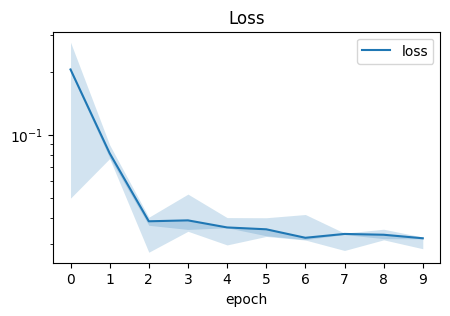

In [9]:
tinstr.plot_train_history(history)

## Instrumented Training

In [24]:
variables = tinstr.VariableHistoryCallback()
gradients = tinstr.GradientHistoryCallback()
outputs = tinstr.LayerOutputHistoryCallback()
output_gradients = tinstr.LayerOutputGradientHistoryCallback()

model = basic_conv_model()
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='mean_squared_error',
    metrics=[]
)
dataset = prepared_dataset().take(6000).batch(32).prefetch(tf.data.AUTOTUNE)
history = tinstr.fit(model, dataset, epochs=50, callbacks=[variables, gradients, outputs, output_gradients, tinstr.HistoryStats(per_step=True)])

Epoch 1/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 9s 39ms/step - loss: 0.0529
Epoch 2/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 0.0301
Epoch 3/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.0281
Epoch 4/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0287
Epoch 5/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - loss: 0.0277
Epoch 6/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.0281
Epoch 7/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 0.0278
Epoch 8/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - loss: 0.0280
Epoch 9/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.0279
Epoch 10/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.0277
Epoch 11/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - loss: 0.0279
Epoch 12/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0275
Epoch 13/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.0279
Epoch 14/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.0267
Epoch 15/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 3s

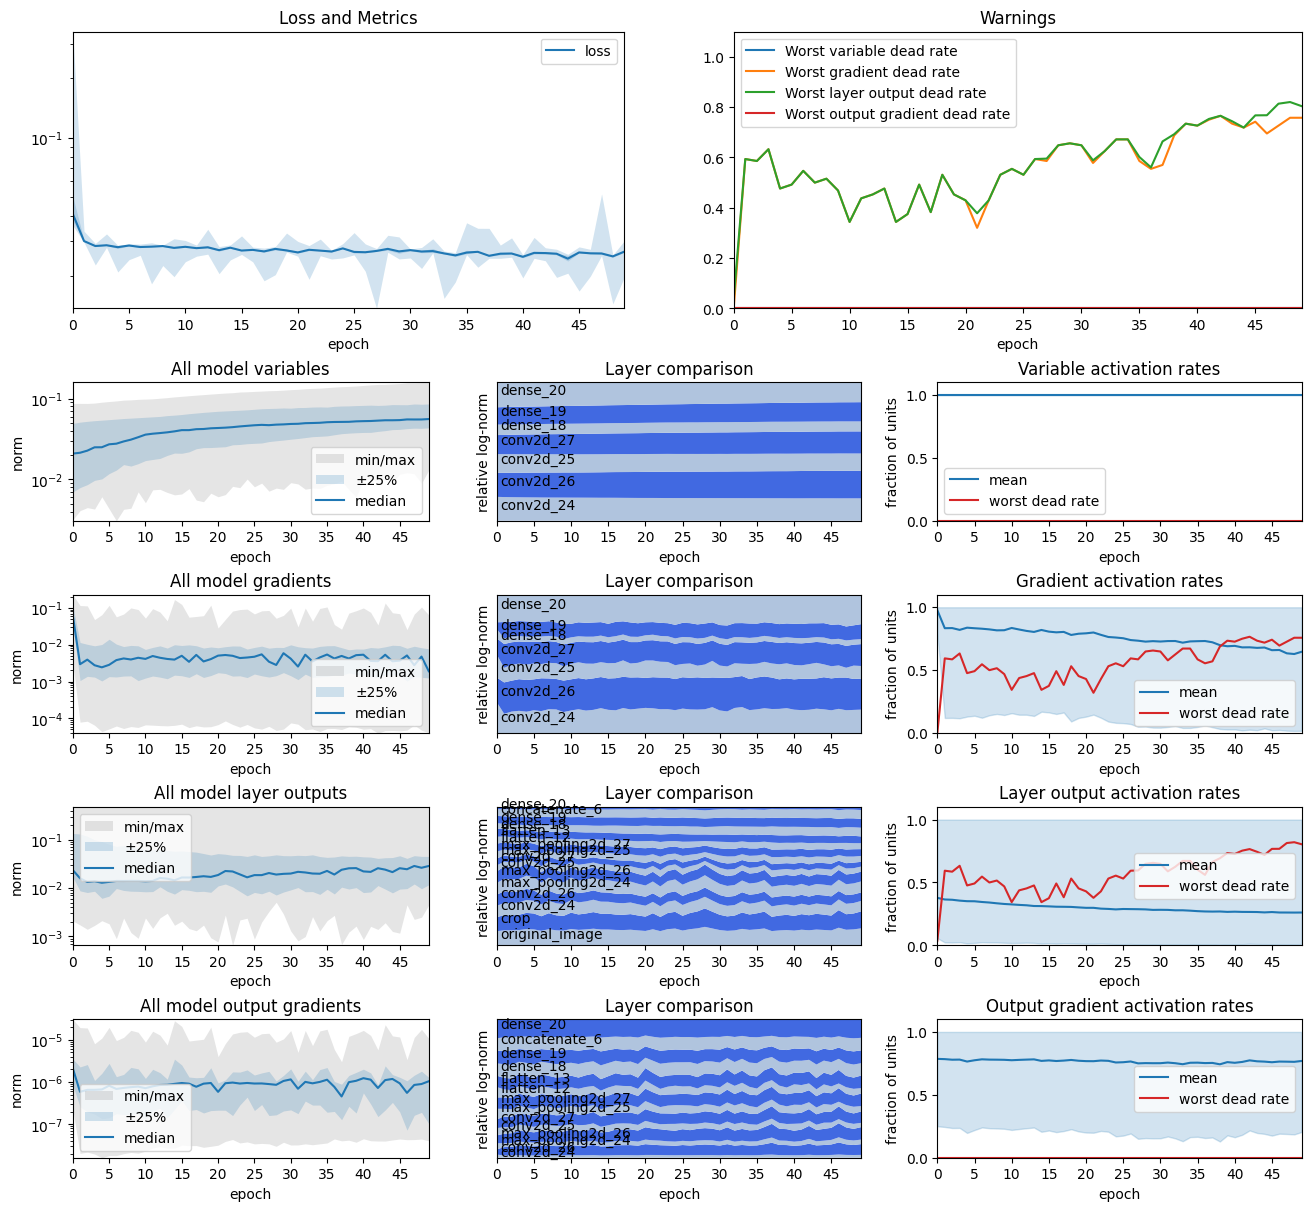

In [25]:
tinstr.plot_history_overview([history, variables, gradients, outputs, output_gradients])

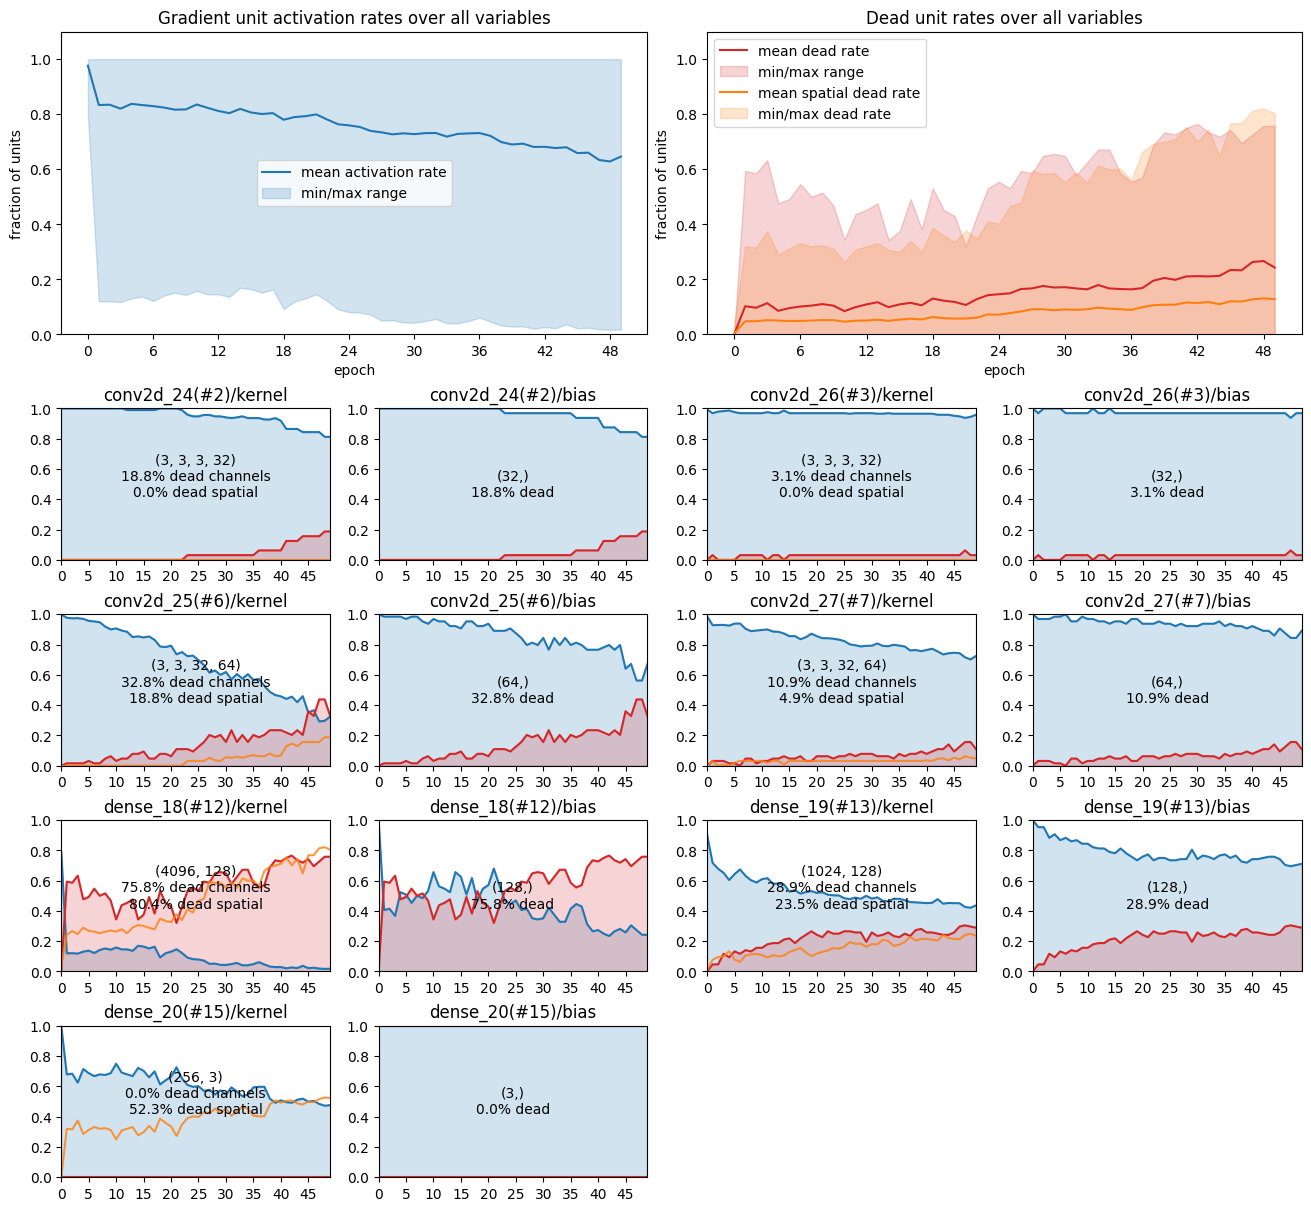

In [26]:
tinstr.plot_activity_history(gradients)

In [27]:
_, _, layer_channel_activity, layer_spatial_activity = tinstr.measure_unit_activity(model, dataset, include_channel_activity=True, include_spatial_activity=True)

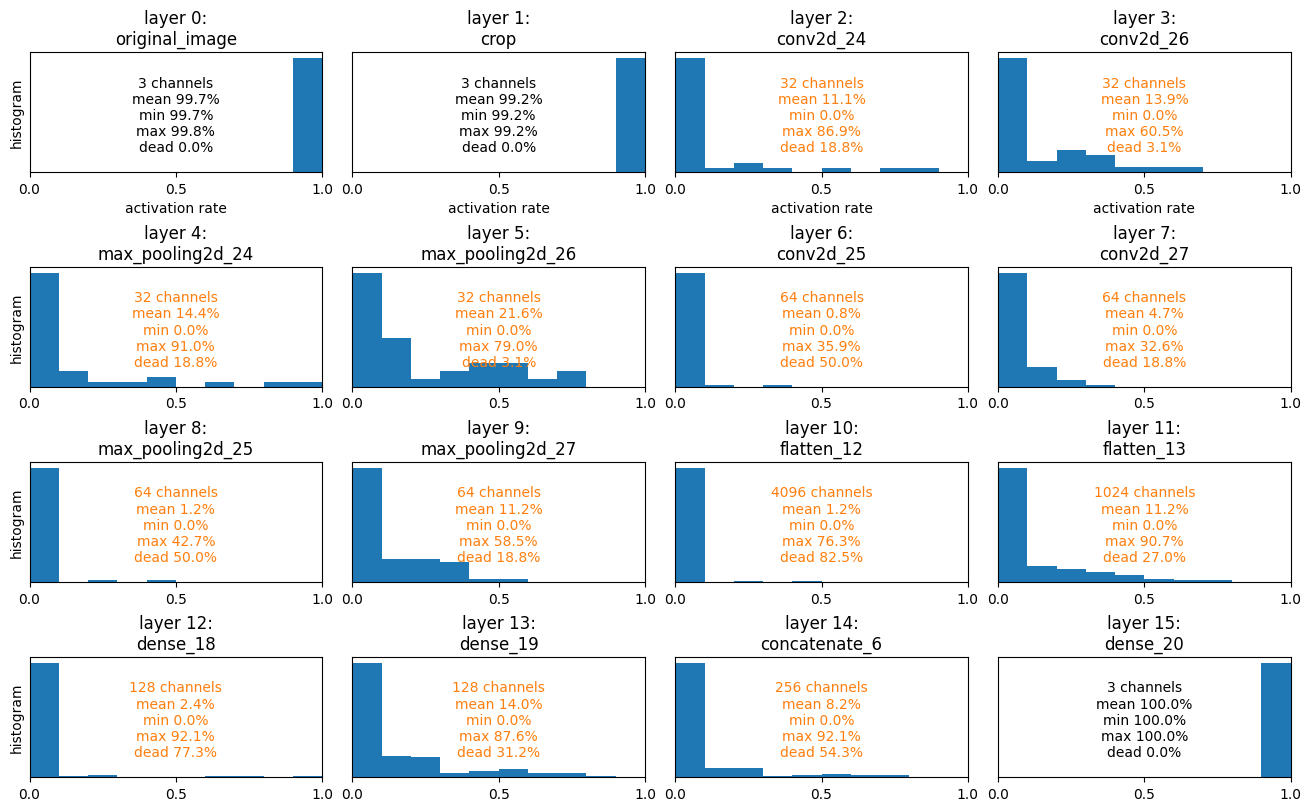

In [28]:
tinstr.plot_channel_stats(layer_channel_activity, model)

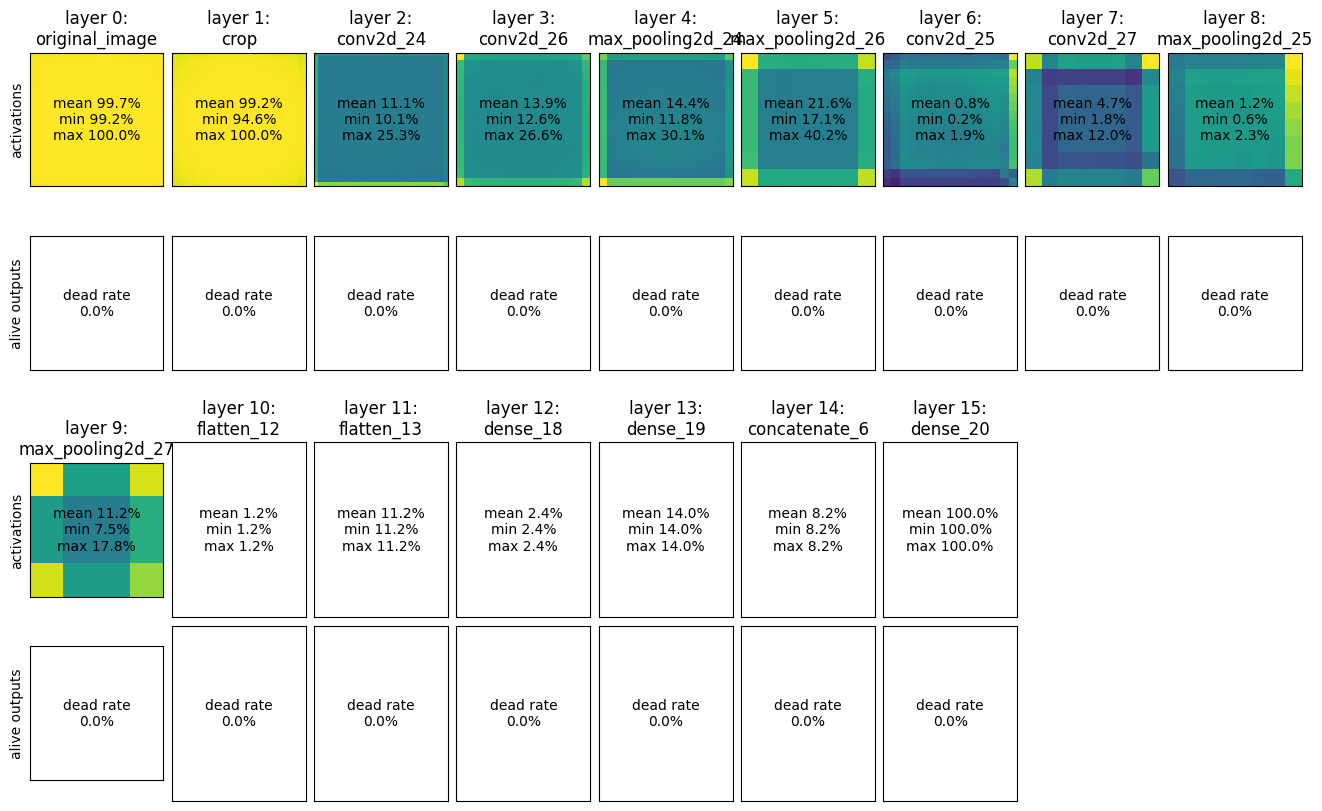

In [29]:
tinstr.plot_spatial_stats(layer_spatial_activity, model)